# Load

In [1]:
library(rhdf5)
library(data.table)
library(ggplot2)
library(LeyLabRMisc)

Warning message:
“replacing previous import ‘data.table::last’ by ‘tidytable::last’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘tidytable::first’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘tidytable::between’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::%notin%’ by ‘tidytable::%notin%’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::fread’ by ‘tidytable::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::fread’ by ‘data.table::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::distinct’ by ‘dplyr::distinct’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::filter’ by ‘dplyr::filter’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::mutate’ by ‘dplyr::mutate’ w

In [2]:
work_dir = ".."

# Calculation of contacts profile

In [3]:
get_profile <- function(
  h5file,
  chrX,
  chrY
) {
  library(rhdf5)
  library(data.table)

  # ---- Read intervals ----
  chr   <- h5read(h5file, "intervals/chr_list")
  start <- h5read(h5file, "intervals/start_list")
  end   <- h5read(h5file, "intervals/end_list")

  bins <- data.table(
    bin   = seq_along(chr) - 1,  # 0-based
    chr   = chr,
    start = start,
    end   = end
  )

  bins_X <- bins[chr == chrX, bin]
  bins_Y <- bins[chr == chrY, bin]

  if (length(bins_X) == 0 || length(bins_Y) == 0) {
    stop("One of the chromosomes has no bins in the matrix.")
  }

  # ---- Read sparse matrix ----
  data    <- h5read(h5file, "matrix/data")
  indices <- h5read(h5file, "matrix/indices")
  indptr  <- h5read(h5file, "matrix/indptr")

  # ---- Initialize signal ----
  signal_Y <- setNames(numeric(length(bins_Y)), bins_Y)

  # ---- Symmetry-aware accumulation ----
  for (i in seq_len(length(indptr) - 1) - 1) {

    row_start <- indptr[i + 1] + 1
    row_end   <- indptr[i + 2]

    if (row_start > row_end) next

    cols <- indices[row_start:row_end]
    vals <- data[row_start:row_end]

    # Case 1: row in X, col in Y
    if (i %in% bins_X) {
      keep <- cols %in% bins_Y
      if (any(keep)) {
        signal_Y[as.character(cols[keep])] <-
          signal_Y[as.character(cols[keep])] + vals[keep]
      }
    }

    # Case 2: row in Y, col in X (mirror)
    if (i %in% bins_Y) {
      keep <- cols %in% bins_X
      if (any(keep)) {
        signal_Y[as.character(i)] <-
          signal_Y[as.character(i)] + sum(vals[keep])
      }
    }
  }

  # ---- Output table ----
  out <- bins[bin %in% bins_Y]
  out[, contacts := signal_Y[as.character(bin)]]

  out[, contacts_norm_len := contacts / length(bins_X)]
  cpm_min <- quantile(out$contacts_norm_len, 0.02)
  cpm_max <- quantile(out$contacts_norm_len, 0.98)
  out[, contacts_norm := pmax(0, pmin(1, (contacts_norm_len - cpm_min) / (cpm_max - cpm_min)))]
  return(out[])
}

In [4]:
# Specify file and sequences to plot
h5_file = file.path(work_dir, "data/synthetic_community/Hicexplorer/contact_matrix_5000b.h5")
chrX <- "P_nigrescens_chr2"
chrX_name <- "chromosome 2"
chrY <- "P_nigrescens_chr1"
chrY_name <- "chromosome 1"

In [5]:
profile_XY <- get_profile(h5_file, chrX, chrY)
profile_YX <- get_profile(h5_file, chrY, chrX)

In [6]:
#Check that the sum of the contacts is the same for both profiles
sum(profile_XY$contacts)
sum(profile_YX$contacts)

[1] 2274033

[1] 2274033

In [7]:
# Step 1: Define window size (e.g., 12.5% of total rows)
window_size_XY <- round(nrow(profile_XY) * 0.125)
if (window_size_XY %% 2 == 0) window_size_XY <- window_size_XY + 1  # Ensure odd window size
window_size_YX <- round(nrow(profile_YX) * 0.125)
if (window_size_YX %% 2 == 0) window_size_YX <- window_size_YX + 1  # Ensure odd window size

# Step 2: Create circular extension of the data
# We'll pad the data at both ends: take the last `half_window` rows and prepend them,
# and take the first `half_window` rows and append them.
half_window_XY <- (window_size_XY - 1) %/% 2
half_window_YX <- (window_size_YX - 1) %/% 2


# Extend the data: wrap around
extended_data_XY <- rbind(
  profile_XY[(nrow(profile_XY) - half_window_XY + 1):nrow(profile_XY), ],  # last half_window rows
  profile_XY,
  profile_XY[1:half_window_XY, ]  # first half_window rows
)
extended_data_YX <- rbind(
  profile_YX[(nrow(profile_YX) - half_window_YX + 1):nrow(profile_YX), ],  # last half_window rows
  profile_YX,
  profile_YX[1:half_window_YX, ]  # first half_window rows
)

# Step 3: Apply frollmean on extended data
extended_data_XY[, contacts_smooth_circular := frollmean(contacts_norm, n = window_size_XY, align = "center", na.rm = TRUE)]
extended_data_YX[, contacts_smooth_circular := frollmean(contacts_norm, n = window_size_YX, align = "center", na.rm = TRUE)]

# Step 4: Extract only the central part (original data range)
# The original data starts at row `half_window + 1` and ends at `half_window + nrow(profile_XY)`
start_idx_XY <- half_window_XY + 1
end_idx_XY <- half_window_XY + nrow(profile_XY)
start_idx_YX <- half_window_YX + 1
end_idx_YX <- half_window_YX + nrow(profile_YX)

# Extract the smoothed values for the original data
profile_XY[, contacts_smooth := extended_data_XY[start_idx_XY:end_idx_XY, contacts_smooth_circular]]
profile_YX[, contacts_smooth := extended_data_YX[start_idx_YX:end_idx_YX, contacts_smooth_circular]]

In [8]:
# Step 3: Apply frollmean on extended data
extended_data_XY[, contacts_smooth_circular_len := frollmean(contacts_norm_len, n = window_size_XY, align = "center", na.rm = TRUE)]
extended_data_YX[, contacts_smooth_circular_len := frollmean(contacts_norm_len, n = window_size_YX, align = "center", na.rm = TRUE)]

# Step 4: Extract only the central part (original data range)
# The original data starts at row `half_window + 1` and ends at `half_window + nrow(profile_XY)`
start_idx_XY <- half_window_XY + 1
end_idx_XY <- half_window_XY + nrow(profile_XY)
start_idx_YX <- half_window_YX + 1
end_idx_YX <- half_window_YX + nrow(profile_YX)

# Extract the smoothed values for the original data
profile_XY[, contacts_smooth_len := extended_data_XY[start_idx_XY:end_idx_XY, contacts_smooth_circular_len]]
profile_YX[, contacts_smooth_len := extended_data_YX[start_idx_YX:end_idx_YX, contacts_smooth_circular_len]]

# Visualization

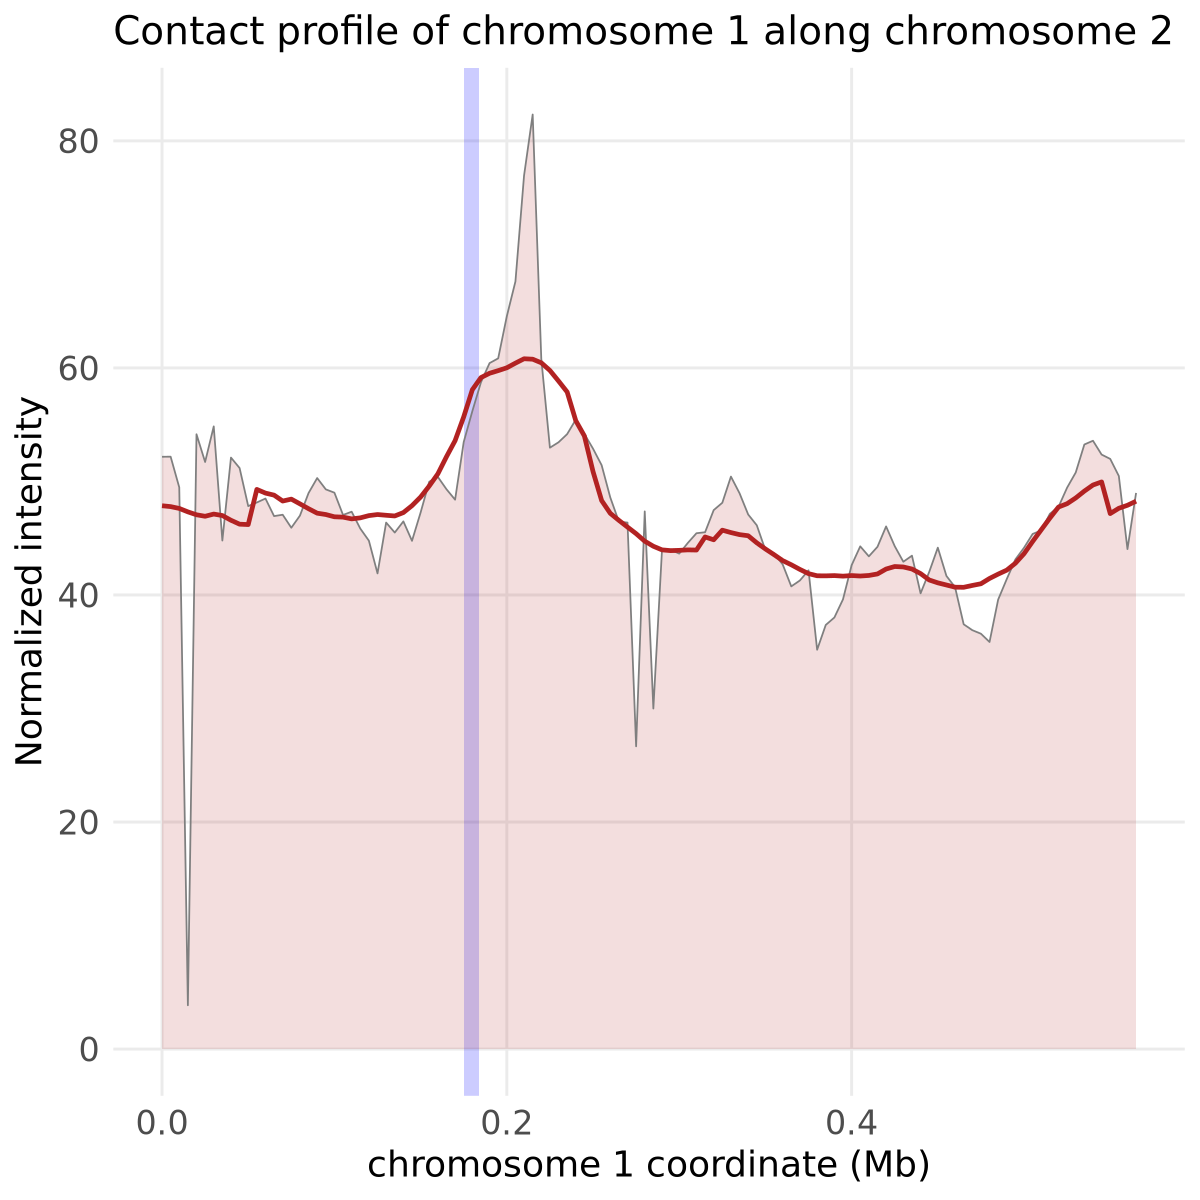

In [9]:
p.dims(6,6)
# Plot the contacts of every region in chrY (X axis) against chrX (Y axis)
profile_XY[, pos_Mb := start / 1e6]

bin_size_kb <- median(profile_XY$end - profile_XY$start) / 1e3

ggplot(profile_XY, aes(x = pos_Mb, y = contacts_norm_len)) +
  annotate("rect", xmin = 175142 / 1e6, xmax = 183692 / 1e6, ymin = -Inf, ymax = Inf, fill = "blue", alpha = 0.2) +
  geom_ribbon(aes(ymin = 0, ymax = contacts_norm_len), fill = "firebrick", alpha = 0.15) +
  geom_line(aes(y = contacts_norm_len), linewidth = 0.3, color = "grey50") +
  geom_line(aes(y = contacts_smooth_len), linewidth = 0.8, color = "firebrick") +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrY_name, "along", chrX_name),
    x = paste(chrY_name, "coordinate (Mb)"),
    y = "Normalized intensity"
  ) +
 theme_minimal() +
  theme(
    axis.text = element_text(size = 12),      # tick labels
    axis.title = element_text(size = 13),     # x and y axis labels
    plot.title = element_text(size = 14),      # main plot title
    panel.grid.minor = element_blank()
  )

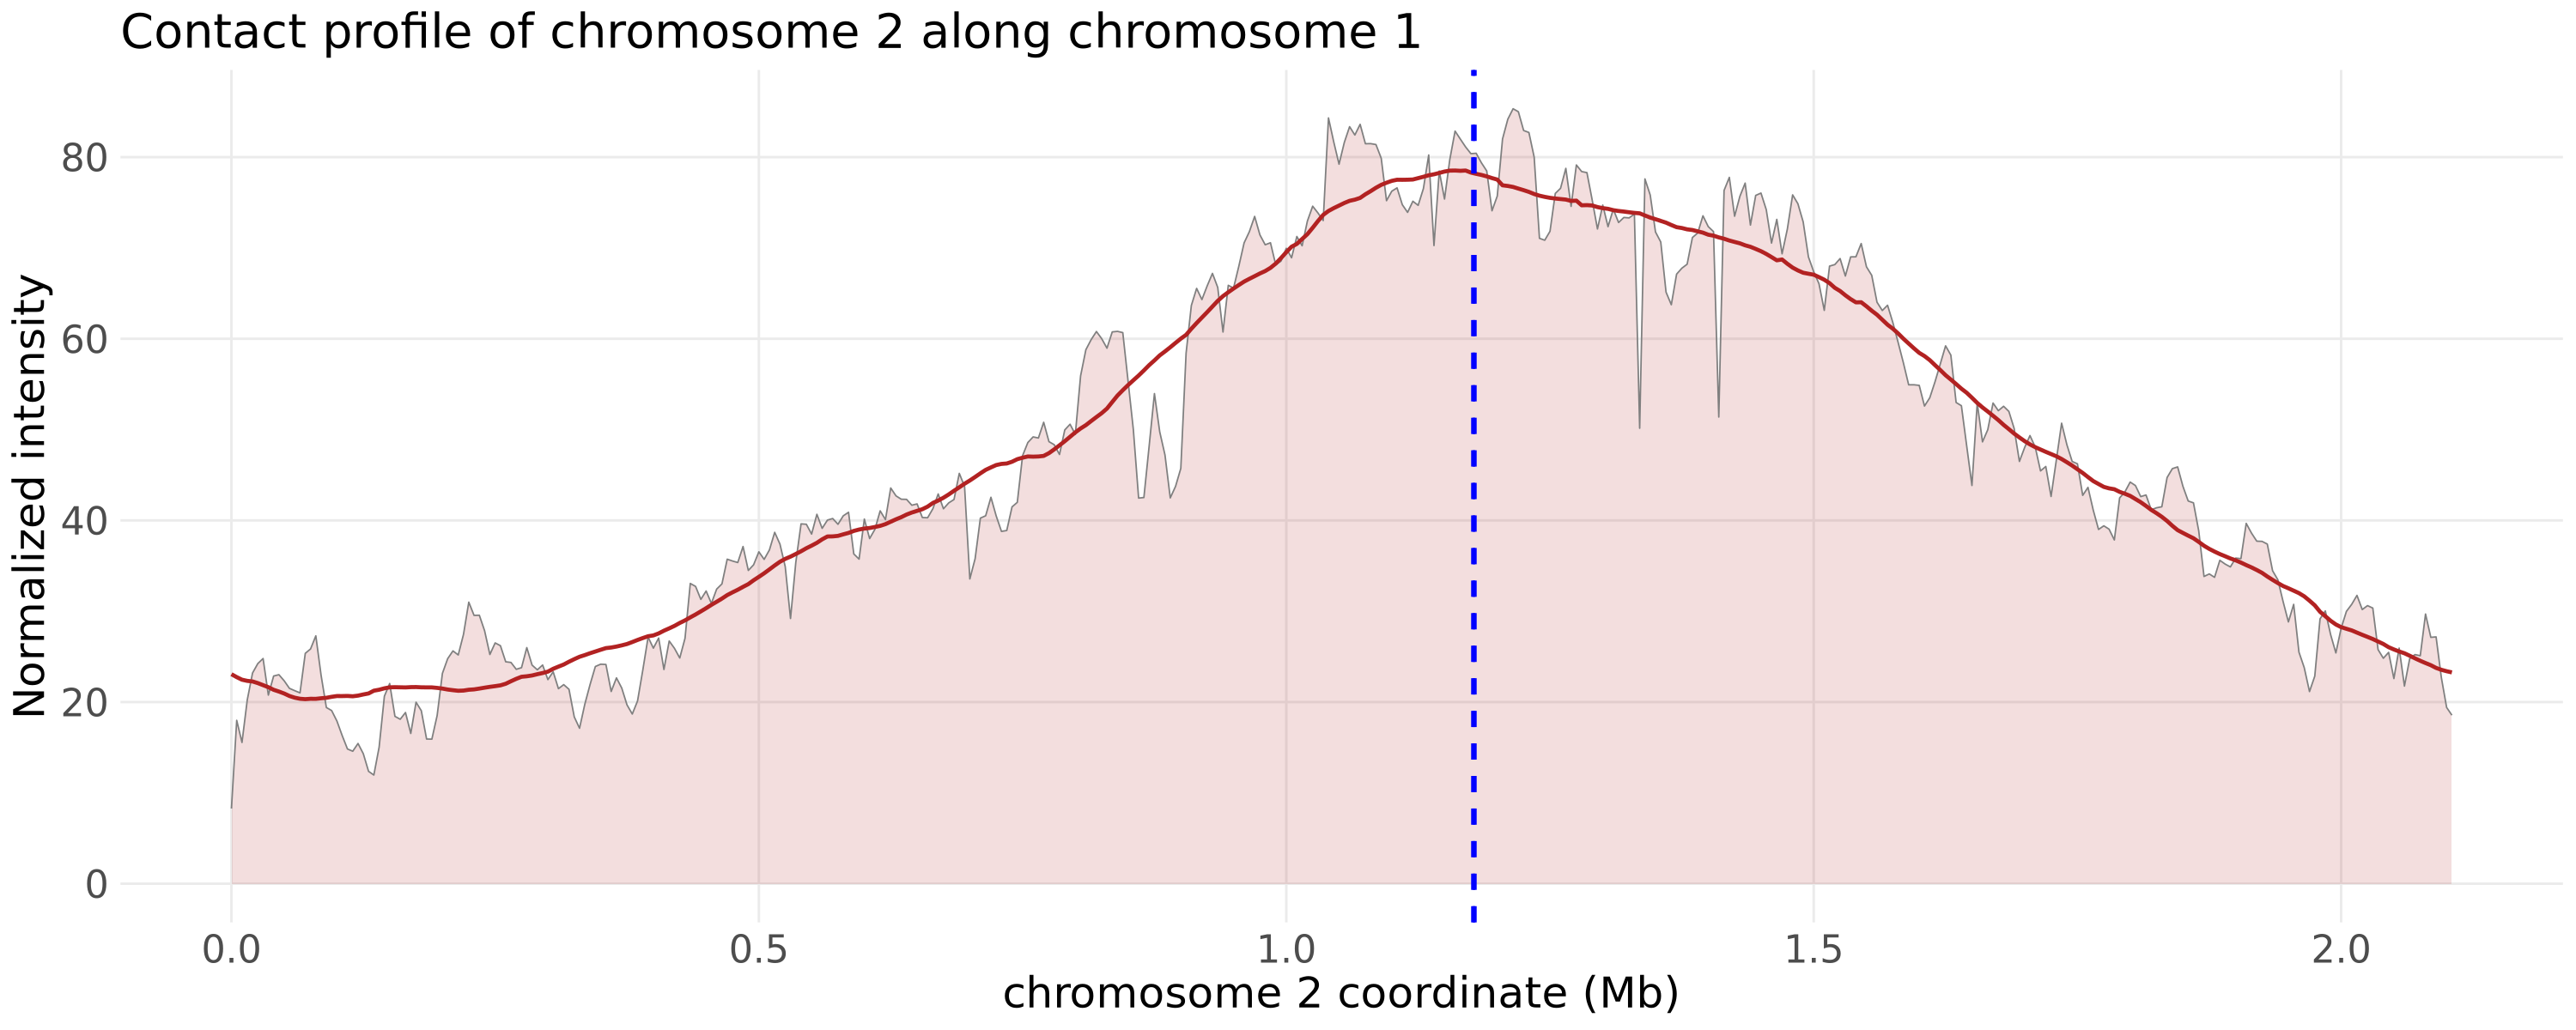

In [10]:
p.dims(15,6)
# Plot the contacts of every region in chrX (X axis) against chrY (Y axis)
profile_YX[, pos_Mb := start / 1e6]

bin_size_kb <- median(profile_YX$end - profile_YX$start) / 1e3

#ggplot(profile_YX, aes(x = start, y = contacts)) +
ggplot(profile_YX, aes(x = pos_Mb, y = contacts_norm_len)) +
  geom_ribbon(aes(ymin = 0, ymax = contacts_norm_len), fill = "firebrick", alpha = 0.15) +
  geom_line(aes(y = contacts_norm_len), linewidth = 0.3, color = "grey50") +
  geom_line(aes(y = contacts_smooth_len), linewidth = 0.8, color = "firebrick") +
  geom_vline(xintercept = 1177147 / 1e6, color = "blue", linewidth = 0.8, linetype = "dashed") +
  geom_vline(xintercept = 1178553 / 1e6, color = "blue", linewidth = 0.8, linetype = "dashed") +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrX_name, "along", chrY_name),
    x = paste(chrX_name, "coordinate (Mb)"),
    y = "Normalized intensity"
  ) + theme_minimal() +
  theme(
    axis.text = element_text(size = 16),      # tick labels
    axis.title = element_text(size = 18),     # x and y axis labels
    plot.title = element_text(size = 20),
    panel.grid.minor = element_blank()      # main plot title
  )